# Fraud Detection - Notebook 1: Setup and EDA

**IEEE-CIS Fraud Detection | XGBoost + LightGBM + Graph Features + Drift Detection**

### Notebooks in this series
| # | Notebook | Contents |
|---|---|---|
| 1 | Setup and EDA | Environment, GPU check, class distribution, feature analysis, t-SNE, UMAP |
| 2 | Features and Sequences | Sequence builder, graph features, save artefacts |
| 3 | XGBoost Classifier | GPU-accelerated supervised model, cross-validated |
| 4 | XGBoost + LightGBM Ensemble | Meta-learner, SHAP, Precision@K, cost analysis |
| 5 | Drift Detection and Retraining | ADWIN, Page-Hinkley, MLflow pipeline |

### EDA sections
1. Environment and GPU check
2. Class distribution
3. Transaction amount analysis
4. Temporal patterns
5. Feature separability (KS test)
6. Correlation structure
7. Card and identity feature analysis
8. t-SNE — 2D fraud cluster visualisation
9. UMAP — faster alternative to t-SNE with better global structure

### Kaggle datasets required
- `ieee-fraud-detection` competition dataset (already mounted)
- `youssefmousaaid/fraud-detection-src` — your uploaded src/ folder

Enable GPU: **Settings -> Accelerator -> GPU T4 x2**

In [1]:
import subprocess, sys
# scipy and seaborn must be pinned — the pre-installed scipy on this Kaggle
# environment is newer than what the installed numpy supports, causing
# AttributeError on import. Pinning fixes the conflict.
# IMPORTANT: restart the kernel after this cell if seaborn still fails.
for pkg in ['networkx', 'umap-learn', 'scipy==1.11.4', 'seaborn==0.13.2']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)
print('Packages ready')
print('Restart kernel if seaborn/scipy still fails to import')

Packages ready
Restart kernel if seaborn/scipy still fails to import


In [2]:
import sys, json, numpy as np, pandas as pd, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

IEEE_DIR  = Path('/kaggle/input/competitions/ieee-fraud-detection')
SRC_DIR   = Path('/kaggle/input/datasets/youssefmousaaid/fraud-detection-src')
WORK_DIR  = Path('/kaggle/working')
PROC_DIR  = WORK_DIR / 'processed'
MDL_DIR   = WORK_DIR / 'models'
OUT_DIR   = WORK_DIR / 'outputs'

for d in [PROC_DIR, MDL_DIR, OUT_DIR,
          OUT_DIR/'eda', OUT_DIR/'graph', OUT_DIR/'model',
          OUT_DIR/'isolation_forest', OUT_DIR/'ensemble',
          OUT_DIR/'drift', OUT_DIR/'pipeline', WORK_DIR/'mlruns']:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SRC_DIR))
print('Paths ready')
print(f'  IEEE data : {IEEE_DIR}')
print(f'  Src code  : {SRC_DIR}')
print(f'  Working   : {WORK_DIR}')

Paths ready
  IEEE data : /kaggle/input/competitions/ieee-fraud-detection
  Src code  : /kaggle/input/datasets/youssefmousaaid/fraud-detection-src
  Working   : /kaggle/working


In [3]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('  WARNING: No GPU detected. Enable via Settings -> Accelerator -> GPU T4 x2')

Device: cpu


In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

plt.rcParams.update({
    'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D27','axes.edgecolor':'#2E3347',
    'text.color':'#E0E0E0','axes.labelcolor':'#E0E0E0','xtick.color':'#9AA0B0',
    'ytick.color':'#9AA0B0','grid.color':'#2E3347','grid.linestyle':'--',
    'font.family':'monospace','legend.facecolor':'#1A1D27','legend.edgecolor':'#2E3347',
})
PAL = {
    'normal' :'#4A90D9',
    'fraud'  :'#E84545',
    'accent' :'#F5A623',
    'green'  :'#4CAF50',
    'purple' :'#A259FF',
}
print('Plot style ready')

Plot style ready


## 1 — Load data

In [5]:
import gc

print('Loading train_transaction.csv ...')
tx  = pd.read_csv(IEEE_DIR / 'train_transaction.csv')
print(f'  Transactions: {len(tx):,} rows x {tx.shape[1]} cols')

print('Loading train_identity.csv ...')
id_ = pd.read_csv(IEEE_DIR / 'train_identity.csv')
print(f'  Identity    : {len(id_):,} rows x {id_.shape[1]} cols')

df = tx.merge(id_, on='TransactionID', how='left')
del tx, id_; gc.collect()
df = df.rename(columns={'isFraud':'Class','TransactionAmt':'Amount','TransactionDT':'Time'})
df = df.sort_values('Time').reset_index(drop=True)

fraud_count  = int(df['Class'].sum())
normal_count = len(df) - fraud_count
fraud_pct    = fraud_count / len(df) * 100

print(f'\nMerged dataset  : {len(df):,} rows x {df.shape[1]} cols')
print(f'  Normal        : {normal_count:>7,}  ({100-fraud_pct:.3f}%)')
print(f'  Fraud         : {fraud_count:>7,}  ({fraud_pct:.3f}%)')
print(f'  Imbalance     : 1 fraud per {normal_count//fraud_count} normal transactions')
print(f'  Cardholders   : {df["card1"].nunique():,} unique card1 IDs')
print(f'  Time span     : {df["Time"].min():,} — {df["Time"].max():,} (seconds)')
print(f'  Memory        : {df.memory_usage(deep=True).sum()/1e6:.0f} MB')

Loading train_transaction.csv ...
  Transactions: 590,540 rows x 394 cols
Loading train_identity.csv ...
  Identity    : 144,233 rows x 41 cols

Merged dataset  : 590,540 rows x 434 cols
  Normal        : 569,877  (96.501%)
  Fraud         :  20,663  (3.499%)
  Imbalance     : 1 fraud per 27 normal transactions
  Cardholders   : 13,553 unique card1 IDs
  Time span     : 86,400 — 15,811,131 (seconds)
  Memory        : 2636 MB


## 2 — Class distribution

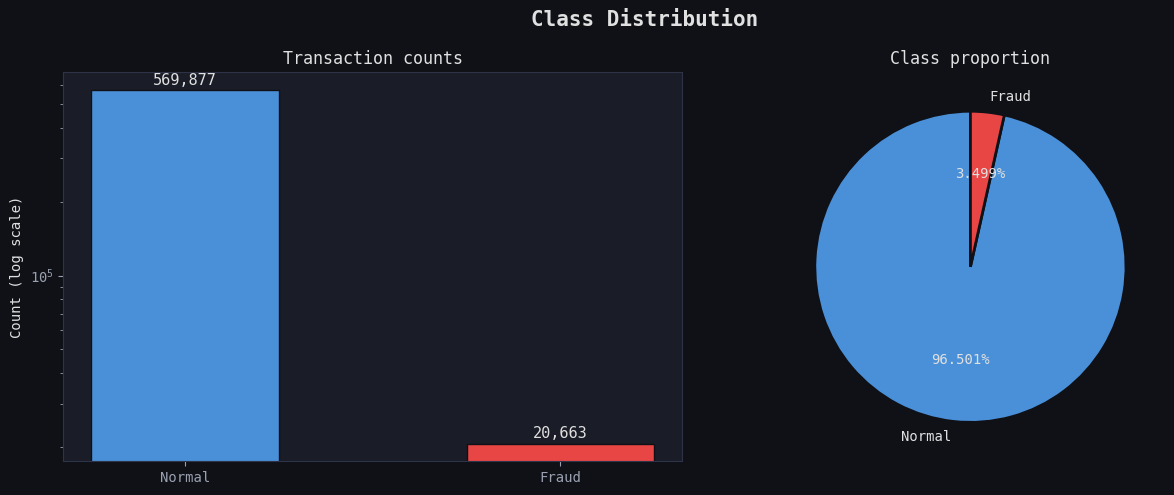

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Class Distribution', fontsize=15, fontweight='bold', color='#E0E0E0')

bars = axes[0].bar(['Normal','Fraud'], [normal_count, fraud_count],
                   color=[PAL['normal'],PAL['fraud']], edgecolor='#0F1117', width=0.5)
for bar, val in zip(bars, [normal_count, fraud_count]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.05,
                 f'{val:,}', ha='center', fontsize=11, color='#E0E0E0')
axes[0].set_yscale('log')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Transaction counts', color='#E0E0E0')

axes[1].pie([normal_count, fraud_count], labels=['Normal','Fraud'],
            colors=[PAL['normal'],PAL['fraud']], autopct='%1.3f%%',
            textprops={'color':'#E0E0E0'},
            wedgeprops={'edgecolor':'#0F1117','linewidth':2},
            startangle=90)
axes[1].set_title('Class proportion', color='#E0E0E0')

plt.tight_layout()
plt.savefig(OUT_DIR/'eda/01_class_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

## 3 — Transaction amount analysis

Transaction amount statistics:
           count    mean     std   min    25%   50%    75%     90%     99%       max
Normal  569877.0  134.51  239.40  0.25  43.97  68.5  120.0  267.11  1104.0  31937.39
Fraud    20663.0  149.24  232.21  0.29  35.04  75.0  161.0  335.00   994.0   5191.00


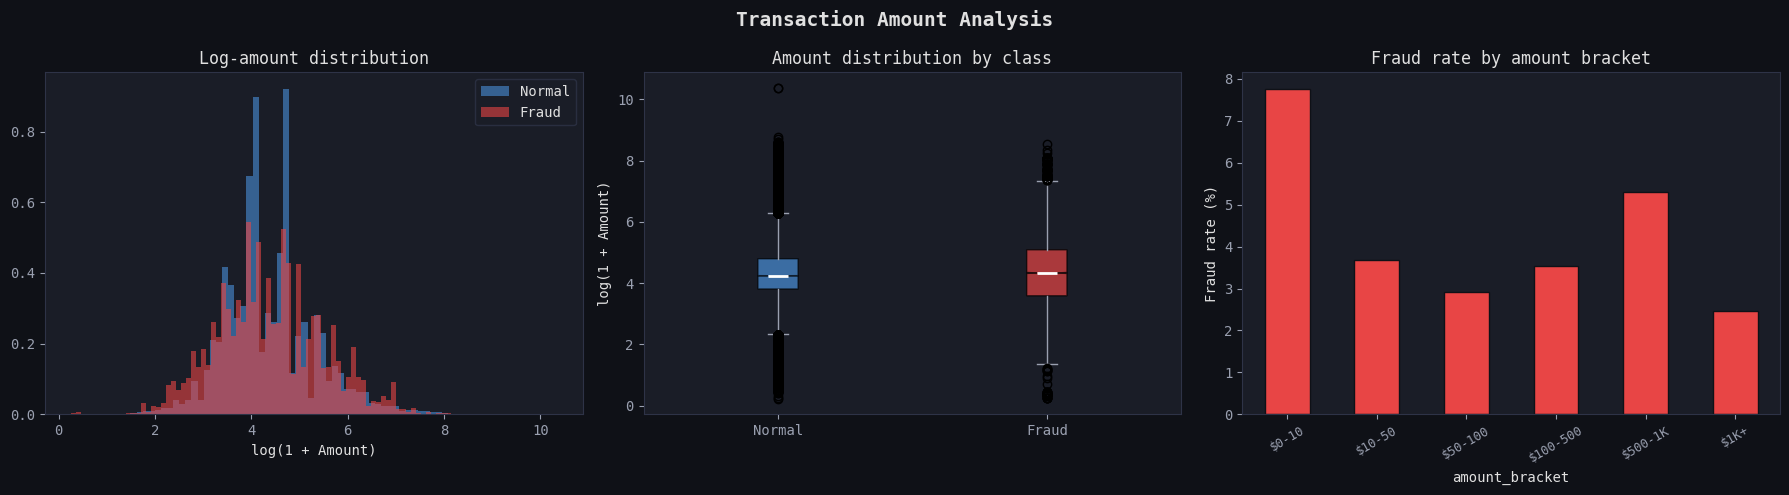

In [7]:
# Summary statistics
amt_stats = df.groupby('Class')['Amount'].describe(percentiles=[.25,.5,.75,.90,.99])
amt_stats.index = ['Normal','Fraud']
print('Transaction amount statistics:')
print(amt_stats.round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Transaction Amount Analysis', fontsize=14, fontweight='bold', color='#E0E0E0')

# Log-amount distribution
for cls, lbl, col in [(0,'Normal',PAL['normal']),(1,'Fraud',PAL['fraud'])]:
    vals = np.log1p(df[df['Class']==cls]['Amount'].dropna())
    axes[0].hist(vals, bins=80, alpha=0.6, color=col, label=lbl, density=True)
axes[0].set_xlabel('log(1 + Amount)')
axes[0].set_title('Log-amount distribution', color='#E0E0E0')
axes[0].legend()

# Amount by class — box plot
norm_amt  = np.log1p(df[df['Class']==0]['Amount'].dropna().values)
fraud_amt = np.log1p(df[df['Class']==1]['Amount'].dropna().values)
bp = axes[1].boxplot([norm_amt, fraud_amt], labels=['Normal','Fraud'],
                     patch_artist=True, notch=True,
                     medianprops={'color':'white','lw':2})
for patch, col in zip(bp['boxes'], [PAL['normal'],PAL['fraud']]):
    patch.set_facecolor(col); patch.set_alpha(0.7)
for element in ['whiskers','caps','fliers']:
    for line in bp[element]: line.set_color('#9AA0B0')
axes[1].set_ylabel('log(1 + Amount)')
axes[1].set_title('Amount distribution by class', color='#E0E0E0')

# Cumulative fraud amount by transaction amount bracket
df['amount_bracket'] = pd.cut(df['Amount'],
    bins=[0,10,50,100,500,1000,df['Amount'].max()+1],
    labels=['$0-10','$10-50','$50-100','$100-500','$500-1K','$1K+'])
bracket_fraud = df.groupby('amount_bracket', observed=True)['Class'].agg(['sum','count'])
bracket_fraud['rate'] = bracket_fraud['sum'] / bracket_fraud['count'] * 100
bracket_fraud['rate'].plot(kind='bar', ax=axes[2],
    color=PAL['fraud'], edgecolor='#0F1117', rot=30)
axes[2].set_ylabel('Fraud rate (%)')
axes[2].set_title('Fraud rate by amount bracket', color='#E0E0E0')
axes[2].tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR/'eda/02_amount_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

## 4 — Temporal patterns

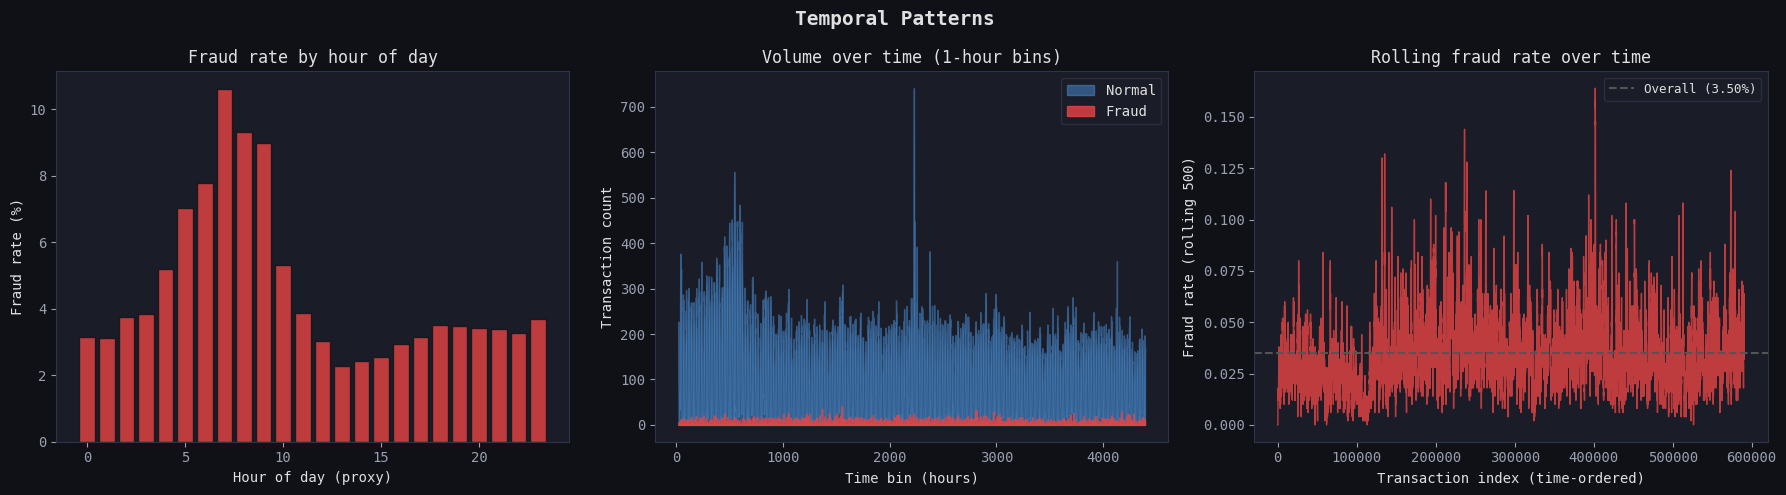

In [8]:
# TransactionDT is seconds elapsed from some reference point.
# Derive hour-of-week (0-167) and day-of-week proxies.
df['hour_of_week'] = (df['Time'] // 3600) % 168
df['hour_of_day']  = (df['Time'] // 3600) % 24
df['day_of_week']  = (df['Time'] // 86400) % 7

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Temporal Patterns', fontsize=14, fontweight='bold', color='#E0E0E0')

# Fraud rate by hour of day
hour_stats = df.groupby('hour_of_day')['Class'].agg(['mean','sum','count']).reset_index()
hour_stats.columns = ['hour','fraud_rate','fraud_count','total']
axes[0].bar(hour_stats['hour'], hour_stats['fraud_rate']*100,
            color=PAL['fraud'], alpha=0.8, edgecolor='#0F1117')
axes[0].set_xlabel('Hour of day (proxy)')
axes[0].set_ylabel('Fraud rate (%)')
axes[0].set_title('Fraud rate by hour of day', color='#E0E0E0')

# Transaction volume over time (rolling)
bin_size  = 3600   # 1-hour bins
df['time_bin'] = df['Time'] // bin_size
time_vol = df.groupby(['time_bin','Class']).size().unstack(fill_value=0)
if 0 in time_vol.columns:
    axes[1].fill_between(time_vol.index, time_vol[0],
                         alpha=0.5, color=PAL['normal'], label='Normal')
if 1 in time_vol.columns:
    axes[1].fill_between(time_vol.index, time_vol[1],
                         alpha=0.8, color=PAL['fraud'], label='Fraud')
axes[1].set_xlabel('Time bin (hours)')
axes[1].set_ylabel('Transaction count')
axes[1].set_title('Volume over time (1-hour bins)', color='#E0E0E0')
axes[1].legend()

# Rolling fraud rate over time
rolling_window = 500
df_sorted = df.sort_values('Time')
rolling_fraud = df_sorted['Class'].rolling(rolling_window, min_periods=50).mean()
axes[2].plot(rolling_fraud.values, color=PAL['fraud'], lw=1, alpha=0.8)
axes[2].axhline(fraud_pct/100, color='#555', ls='--', lw=1.5, label=f'Overall ({fraud_pct:.2f}%)')
axes[2].set_xlabel('Transaction index (time-ordered)')
axes[2].set_ylabel(f'Fraud rate (rolling {rolling_window})')
axes[2].set_title('Rolling fraud rate over time', color='#E0E0E0')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR/'eda/03_temporal_patterns.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

## 5 — Feature separability (KS test on V-features)

Top 10 features by KS statistic (normal vs fraud):
feature  ks_stat  p_value  normal_mean  fraud_mean
    V15   0.3265      0.0       0.1115      0.4446
    V16   0.3265      0.0       0.1125      0.4490
    V18   0.3180      0.0       0.1229      0.5050
    V17   0.3179      0.0       0.1218      0.4967
    V22   0.3147      0.0       0.1218      0.4432
    V21   0.3147      0.0       0.1194      0.4362
    V10   0.2806      0.0       0.4694      0.1887
    V11   0.2803      0.0       0.4846      0.1980
    V13   0.1759      0.0       0.6036      0.4667
    V12   0.1726      0.0       0.5646      0.4140


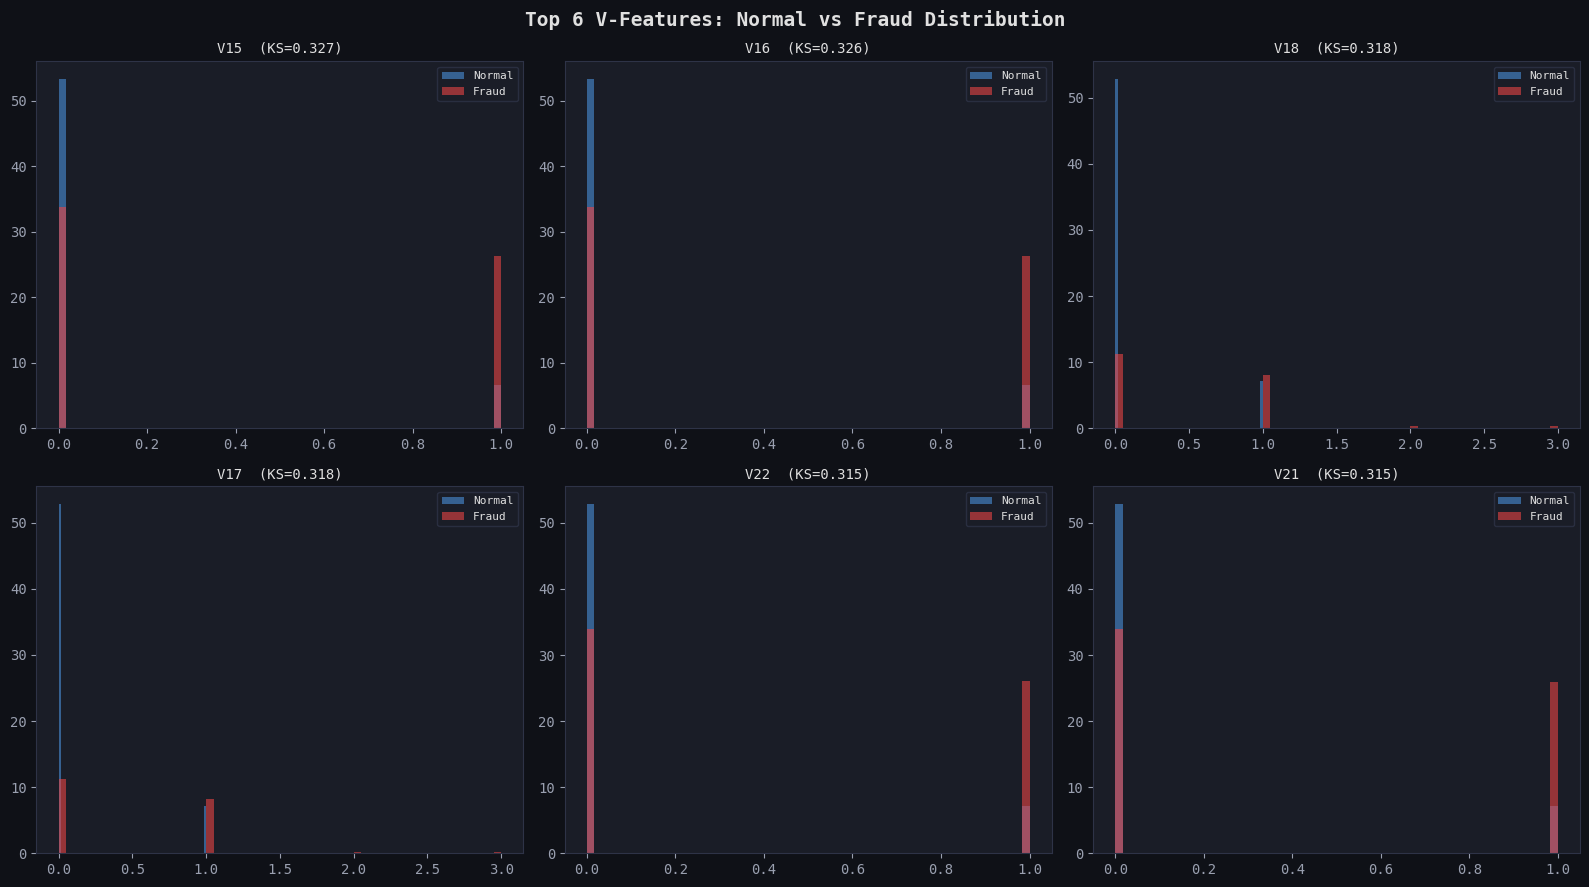

In [9]:
v_features = [c for c in df.columns if c.startswith('V')][:28]
ks_results = []
for feat in v_features:
    a = df.loc[df['Class']==0, feat].dropna()
    b = df.loc[df['Class']==1, feat].dropna()
    if len(a)>10 and len(b)>10:
        stat, pval = stats.ks_2samp(a, b)
        ks_results.append({'feature':feat,'ks_stat':stat,'p_value':pval,
                           'normal_mean':a.mean(),'fraud_mean':b.mean(),
                           'mean_diff':abs(a.mean()-b.mean())})

ks_df = pd.DataFrame(ks_results).sort_values('ks_stat', ascending=False)
print(f'Top 10 features by KS statistic (normal vs fraud):')
print(ks_df.head(10)[['feature','ks_stat','p_value','normal_mean','fraud_mean']]
      .round(4).to_string(index=False))

top_features = ks_df.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Top 6 V-Features: Normal vs Fraud Distribution',
             fontsize=14, fontweight='bold', color='#E0E0E0')
for ax, feat in zip(axes.flat, top_features):
    ks_val = ks_df.loc[ks_df['feature']==feat,'ks_stat'].values[0]
    for cls, label, color in [(0,'Normal',PAL['normal']),(1,'Fraud',PAL['fraud'])]:
        vals = df[df['Class']==cls][feat].dropna()
        vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
        ax.hist(vals, bins=60, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(f'{feat}  (KS={ks_val:.3f})', color='#E0E0E0', fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR/'eda/04_feature_separability.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

## 6 — Correlation structure

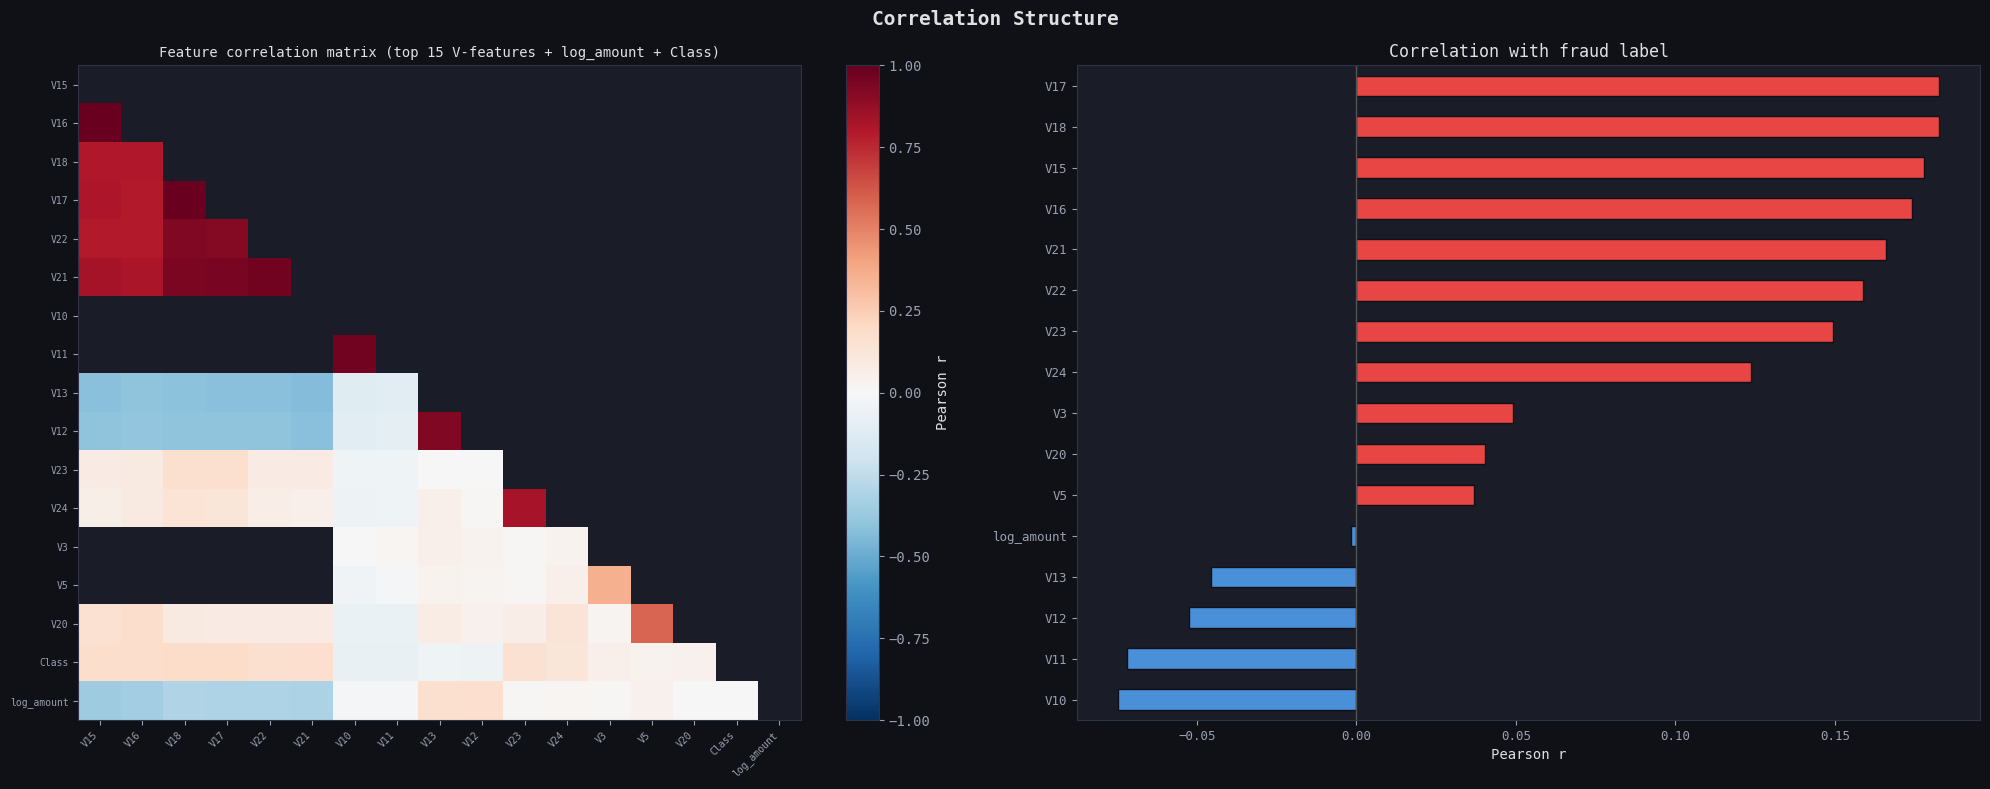

In [10]:
# Correlation heatmap of top V-features + engineered features
top15_feats = ks_df.head(15)['feature'].tolist()
corr_cols   = top15_feats + ['Amount']
corr_data   = df[corr_cols + ['Class']].copy()
corr_data['log_amount'] = np.log1p(corr_data['Amount'])
corr_data = corr_data.drop(columns=['Amount'])

corr_matrix = corr_data.corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Correlation Structure', fontsize=14, fontweight='bold', color='#E0E0E0')

# Lower-triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_masked = corr_matrix.copy()
corr_masked[mask] = np.nan

im = axes[0].imshow(corr_masked, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=axes[0], label='Pearson r')
axes[0].set_xticks(range(len(corr_matrix.columns)))
axes[0].set_yticks(range(len(corr_matrix.columns)))
axes[0].set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=7)
axes[0].set_yticklabels(corr_matrix.columns, fontsize=7)
axes[0].set_title('Feature correlation matrix (top 15 V-features + log_amount + Class)',
                   color='#E0E0E0', fontsize=10)

# Correlation with fraud label
fraud_corr = corr_data.corr()['Class'].drop('Class').sort_values()
colors_bar = [PAL['fraud'] if v > 0 else PAL['normal'] for v in fraud_corr]
fraud_corr.plot(kind='barh', ax=axes[1], color=colors_bar, edgecolor='#0F1117')
axes[1].axvline(0, color='#555', lw=1)
axes[1].set_title('Correlation with fraud label', color='#E0E0E0')
axes[1].set_xlabel('Pearson r')
axes[1].tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR/'eda/05_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

## 7 — Card and identity feature analysis

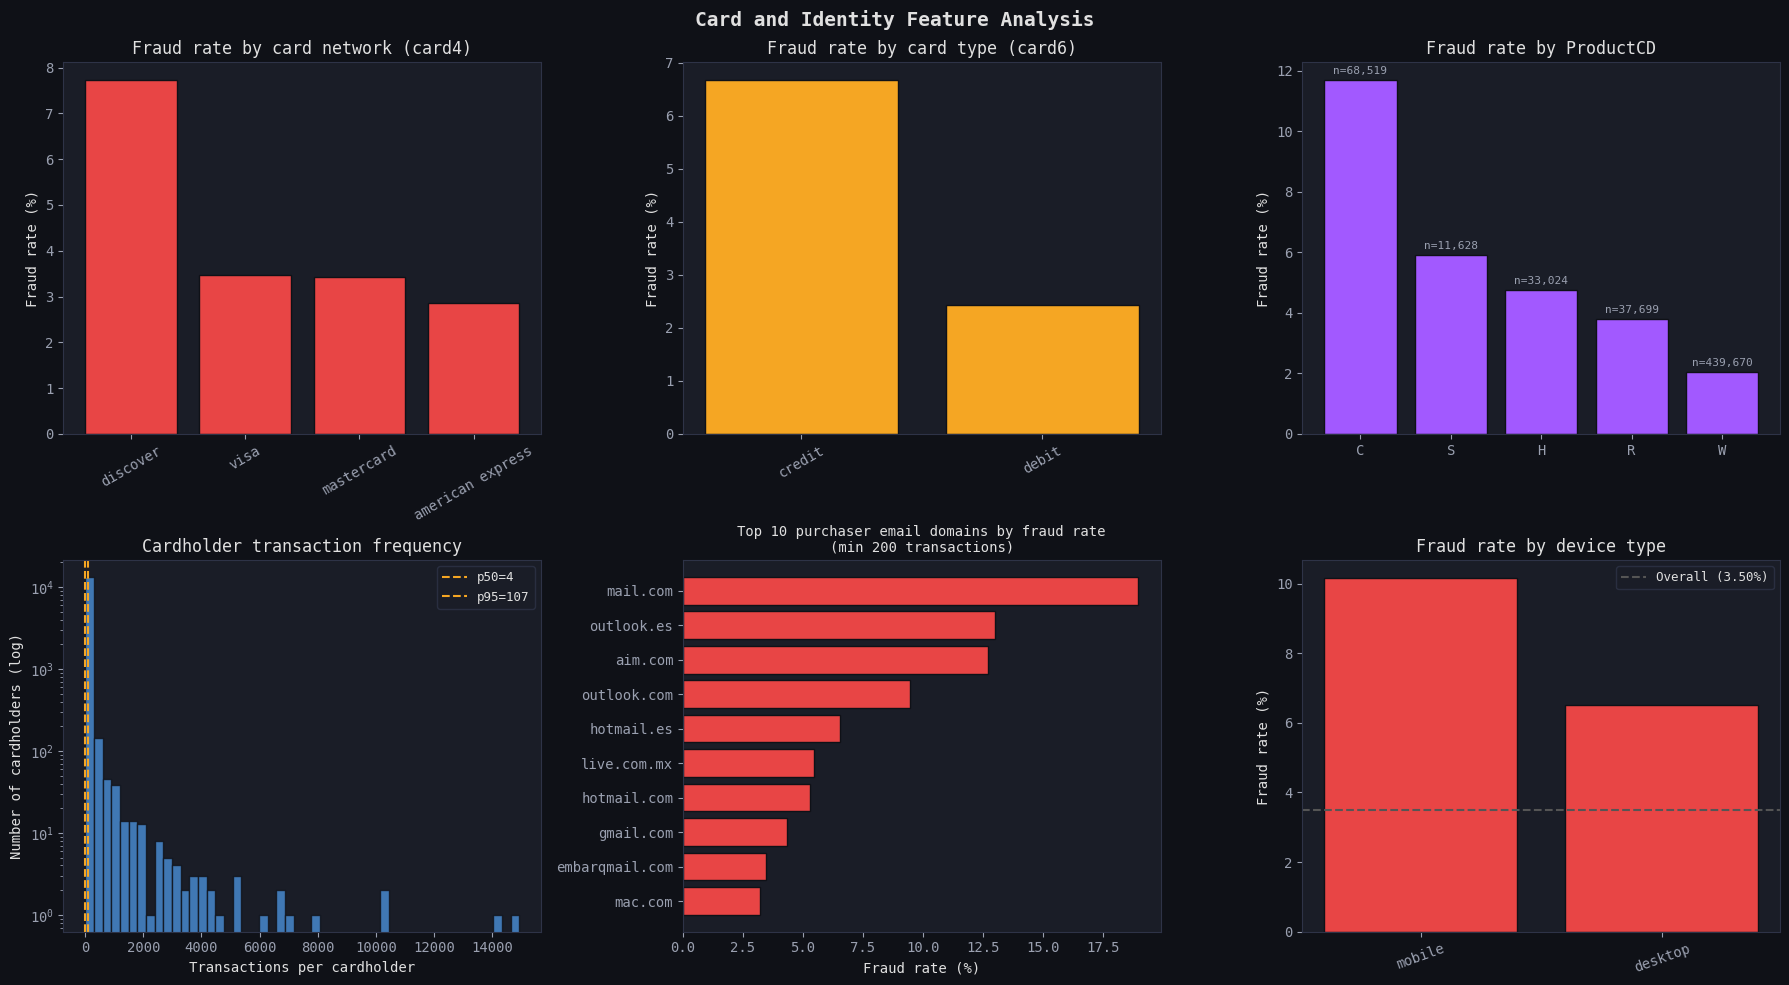

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Card and Identity Feature Analysis', fontsize=14, fontweight='bold', color='#E0E0E0')

# Fraud rate by card4 (card network)
if 'card4' in df.columns:
    c4 = df.groupby('card4')['Class'].agg(['mean','count']).reset_index()
    c4 = c4[c4['count'] > 100].sort_values('mean', ascending=False)
    axes[0,0].bar(c4['card4'].astype(str), c4['mean']*100,
                  color=PAL['fraud'], edgecolor='#0F1117')
    axes[0,0].set_title('Fraud rate by card network (card4)', color='#E0E0E0')
    axes[0,0].set_ylabel('Fraud rate (%)')
    axes[0,0].tick_params(axis='x', rotation=30)

# Fraud rate by card6 (debit/credit)
if 'card6' in df.columns:
    c6 = df.groupby('card6')['Class'].agg(['mean','count']).reset_index()
    c6 = c6[c6['count'] > 100].sort_values('mean', ascending=False)
    axes[0,1].bar(c6['card6'].astype(str), c6['mean']*100,
                  color=PAL['accent'], edgecolor='#0F1117')
    axes[0,1].set_title('Fraud rate by card type (card6)', color='#E0E0E0')
    axes[0,1].set_ylabel('Fraud rate (%)')
    axes[0,1].tick_params(axis='x', rotation=30)

# Fraud rate by ProductCD
if 'ProductCD' in df.columns:
    prod = df.groupby('ProductCD')['Class'].agg(['mean','count']).reset_index()
    prod = prod.sort_values('mean', ascending=False)
    axes[0,2].bar(prod['ProductCD'].astype(str), prod['mean']*100,
                  color=PAL['purple'], edgecolor='#0F1117')
    axes[0,2].set_title('Fraud rate by ProductCD', color='#E0E0E0')
    axes[0,2].set_ylabel('Fraud rate (%)')
    for i, (_, row) in enumerate(prod.iterrows()):
        axes[0,2].text(i, row['mean']*100+0.2, f'n={row["count"]:,}',
                       ha='center', fontsize=8, color='#9AA0B0')

# Card1 frequency distribution
card1_freq = df.groupby('card1').size()
axes[1,0].hist(card1_freq.values, bins=50, color=PAL['normal'],
               edgecolor='#0F1117', alpha=0.8)
axes[1,0].set_yscale('log')
axes[1,0].set_xlabel('Transactions per cardholder')
axes[1,0].set_ylabel('Number of cardholders (log)')
axes[1,0].set_title('Cardholder transaction frequency', color='#E0E0E0')
for pct, val in [(50, card1_freq.median()), (95, card1_freq.quantile(0.95))]:
    axes[1,0].axvline(val, color=PAL['accent'], ls='--', lw=1.5,
                      label=f'p{pct}={val:.0f}')
axes[1,0].legend(fontsize=9)

# P_emaildomain fraud rate (top 10)
if 'P_emaildomain' in df.columns:
    email_fraud = (
        df.groupby('P_emaildomain')['Class']
          .agg(['mean','count'])
          .reset_index()
          .query('count > 200')
          .sort_values('mean', ascending=False)
          .head(10)
    )
    axes[1,1].barh(email_fraud['P_emaildomain'][::-1],
                   email_fraud['mean'][::-1]*100,
                   color=PAL['fraud'], edgecolor='#0F1117')
    axes[1,1].set_xlabel('Fraud rate (%)')
    axes[1,1].set_title('Top 10 purchaser email domains by fraud rate\n(min 200 transactions)',
                        color='#E0E0E0', fontsize=10)

# DeviceType fraud rate
if 'DeviceType' in df.columns:
    dev = df.groupby('DeviceType')['Class'].agg(['mean','count']).reset_index()
    dev = dev[dev['count'] > 100].sort_values('mean', ascending=False)
    colors_dev = [PAL['fraud'] if r['mean'] > fraud_pct/100 else PAL['normal']
                  for _, r in dev.iterrows()]
    axes[1,2].bar(dev['DeviceType'].astype(str), dev['mean']*100,
                  color=colors_dev, edgecolor='#0F1117')
    axes[1,2].axhline(fraud_pct, color='#555', ls='--', lw=1.5,
                      label=f'Overall ({fraud_pct:.2f}%)')
    axes[1,2].set_title('Fraud rate by device type', color='#E0E0E0')
    axes[1,2].set_ylabel('Fraud rate (%)')
    axes[1,2].legend(fontsize=9)
    axes[1,2].tick_params(axis='x', rotation=20)
else:
    axes[1,2].text(0.5, 0.5, 'DeviceType not available\nin merged dataset',
                   ha='center', va='center', transform=axes[1,2].transAxes, color='#9AA0B0')
    axes[1,2].set_title('Fraud rate by device type', color='#E0E0E0')

plt.tight_layout()
plt.savefig(OUT_DIR/'eda/06_card_identity.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

## 8 — t-SNE: fraud cluster visualisation

t-SNE (t-distributed Stochastic Neighbour Embedding) projects high-dimensional feature vectors into 2D while preserving local neighbourhood structure. Fraud transactions that are similar to each other in feature space will appear as clusters. We use the top V-features by KS statistic as input so the projection captures the most discriminative dimensions.

**Notes on interpretation:**
- Cluster separation indicates the model has learnable signal
- Distance between clusters in t-SNE is **not** meaningful — only local structure is preserved
- Perplexity controls the effective neighbourhood size (5–50 is typical)
- We subsample to 5,000 points for speed; stratified to include enough fraud

In [12]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import RobustScaler

# Feature matrix for dimensionality reduction
# Use top 20 V-features by KS stat + log_amount + time_delta proxy
DR_FEATURES = ks_df.head(20)['feature'].tolist()
df['log_amount'] = np.log1p(df['Amount'].fillna(0))
DR_FEATURES = DR_FEATURES + ['log_amount']

# Stratified subsample: all fraud + equal number of normal
NSAMPLE = 5000
fraud_rows  = df[df['Class']==1].index.tolist()
normal_rows = df[df['Class']==0].index.tolist()

np.random.seed(42)
n_fraud_s  = min(len(fraud_rows),  NSAMPLE // 2)
n_normal_s = min(len(normal_rows), NSAMPLE - n_fraud_s)
sel_idx = (
    np.random.choice(fraud_rows,  n_fraud_s,  replace=False).tolist() +
    np.random.choice(normal_rows, n_normal_s, replace=False).tolist()
)
np.random.shuffle(sel_idx)

X_dr = df.loc[sel_idx, DR_FEATURES].fillna(0).values.astype(np.float32)
y_dr = df.loc[sel_idx, 'Class'].values

scaler_dr = RobustScaler()
X_dr_sc   = scaler_dr.fit_transform(X_dr)

print(f'DR sample: {len(sel_idx):,} rows  ({n_fraud_s} fraud + {n_normal_s} normal)')
print(f'Features : {len(DR_FEATURES)}')
print(f'Running t-SNE (perplexity=30, n_iter=1000)...')

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
            random_state=42, n_jobs=-1, verbose=1)
X_tsne = tsne.fit_transform(X_dr_sc)
print(f'Done. KL divergence: {tsne.kl_divergence_:.4f}')

DR sample: 5,000 rows  (2500 fraud + 2500 normal)
Features : 21
Running t-SNE (perplexity=30, n_iter=1000)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.001s...
[t-SNE] Computed neighbors for 5000 samples in 0.187s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.335854
[t-SNE] KL divergence after 1000 iterations: 0.227753
Done. KL divergence: 0.2278


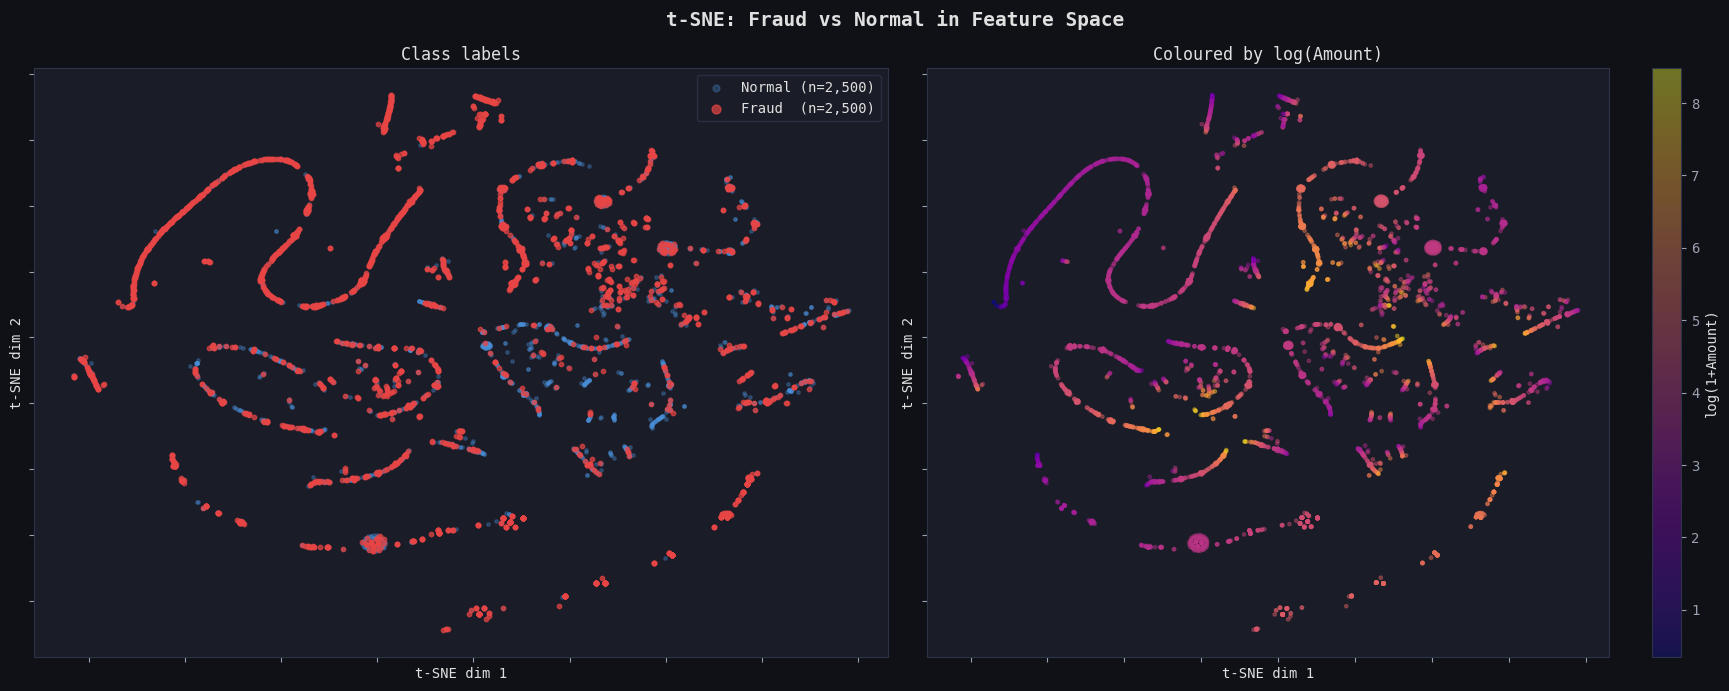

Saved: 07_tsne.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('t-SNE: Fraud vs Normal in Feature Space',
             fontsize=14, fontweight='bold', color='#E0E0E0')

# Panel 1: binary class colouring
normal_mask = (y_dr == 0)
fraud_mask  = (y_dr == 1)

axes[0].scatter(X_tsne[normal_mask, 0], X_tsne[normal_mask, 1],
                c=PAL['normal'], alpha=0.3, s=6, label=f'Normal (n={normal_mask.sum():,})')
axes[0].scatter(X_tsne[fraud_mask,  0], X_tsne[fraud_mask,  1],
                c=PAL['fraud'],  alpha=0.7, s=10, label=f'Fraud  (n={fraud_mask.sum():,})')
axes[0].set_title('Class labels', color='#E0E0E0')
axes[0].legend(fontsize=10, markerscale=2)
axes[0].set_xlabel('t-SNE dim 1'); axes[0].set_ylabel('t-SNE dim 2')
axes[0].tick_params(labelbottom=False, labelleft=False)

# Panel 2: coloured by log(Amount) — do fraud clusters have distinct amounts?
log_amt_sample = np.log1p(df.loc[sel_idx, 'Amount'].fillna(0).values)
sc = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                     c=log_amt_sample, cmap='plasma',
                     alpha=0.4, s=6)
plt.colorbar(sc, ax=axes[1], label='log(1+Amount)')
axes[1].set_title('Coloured by log(Amount)', color='#E0E0E0')
axes[1].set_xlabel('t-SNE dim 1'); axes[1].set_ylabel('t-SNE dim 2')
axes[1].tick_params(labelbottom=False, labelleft=False)

plt.tight_layout()
plt.savefig(OUT_DIR/'eda/07_tsne.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f'Saved: 07_tsne.png')

## 9 — UMAP: faster alternative with better global structure

UMAP (Uniform Manifold Approximation and Projection) is generally faster than t-SNE and better preserves global structure (the relative positions of clusters are more meaningful). It uses a different mathematical framework based on Riemannian geometry and fuzzy simplicial sets.

**Key parameters:**
- `n_neighbors`: controls local vs global structure (15–50 typical)
- `min_dist`: how tightly points are packed together (0.0–0.5)
- `metric`: distance function used in the original high-dimensional space

In [14]:
import umap

print('Running UMAP (n_neighbors=15, min_dist=0.1)...')
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    metric='euclidean', random_state=42, verbose=True)
X_umap = reducer.fit_transform(X_dr_sc)
print('Done.')

2026-05-01 22:27:27.784858: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777674448.030904     297 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777674448.106798     297 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777674448.711942     297 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777674448.711989     297 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777674448.711992     297 computation_placer.cc:177] computation placer alr

Running UMAP (n_neighbors=15, min_dist=0.1)...
UMAP(n_jobs=1, random_state=42, verbose=True)
Fri May  1 22:27:59 2026 Construct fuzzy simplicial set
Fri May  1 22:27:59 2026 Finding Nearest Neighbors
Fri May  1 22:27:59 2026 Building RP forest with 9 trees
Fri May  1 22:28:03 2026 NN descent for 12 iterations
	 1  /  12
	 2  /  12
	Stopping threshold met -- exiting after 2 iterations
Fri May  1 22:28:19 2026 Finished Nearest Neighbor Search
Fri May  1 22:28:21 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri May  1 22:28:36 2026 Finished embedding
Done.


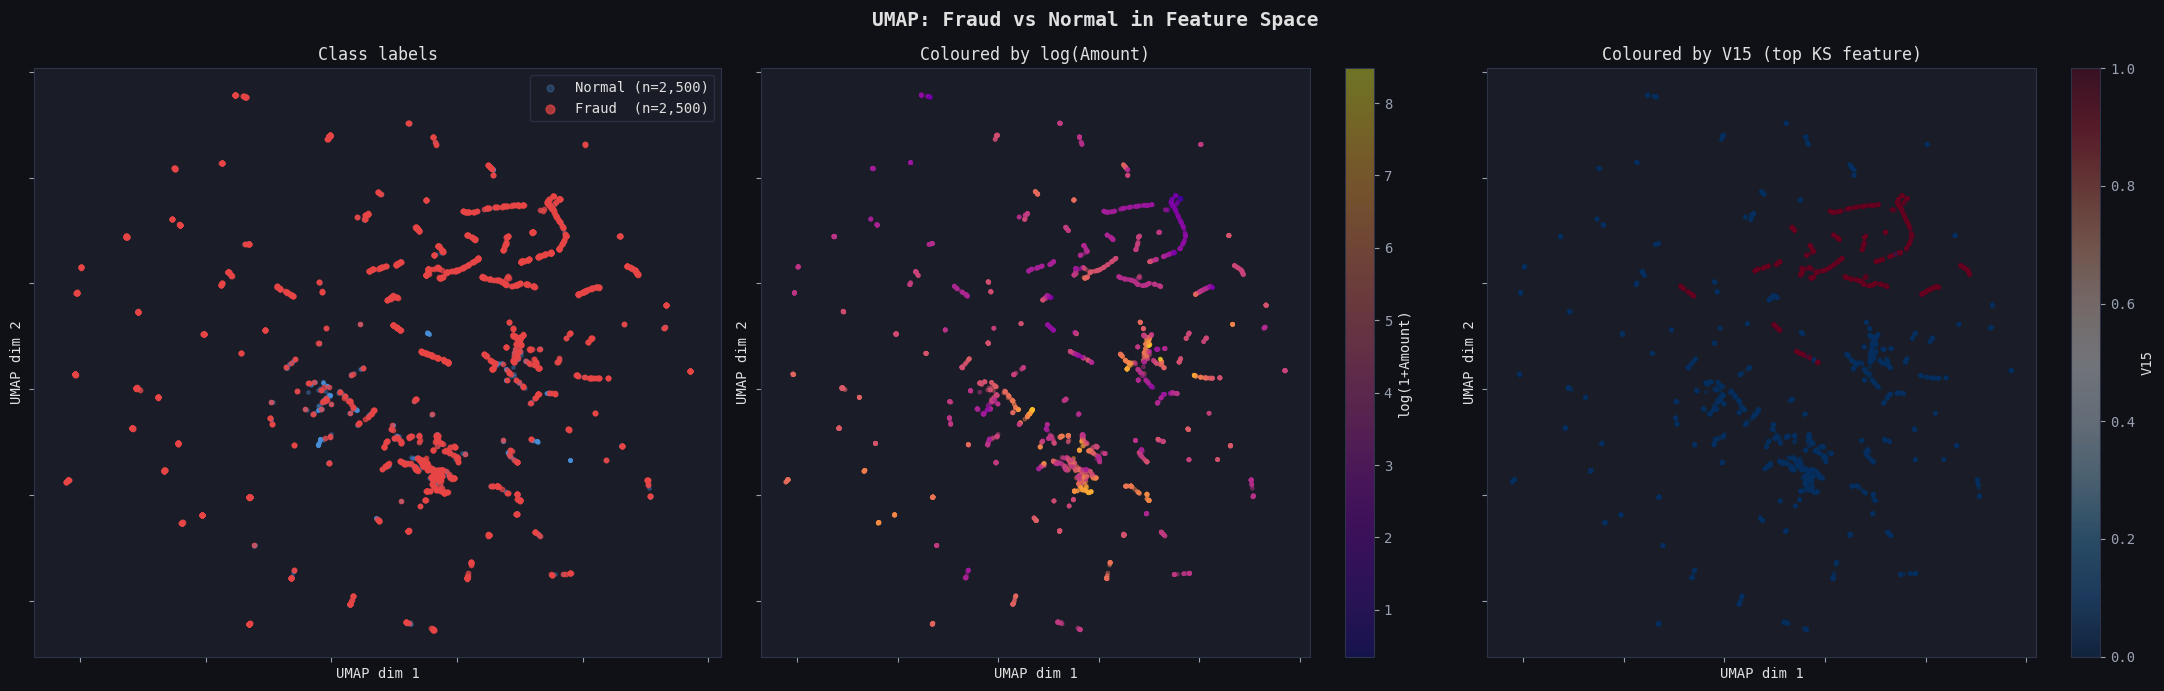

Saved: 08_umap.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('UMAP: Fraud vs Normal in Feature Space',
             fontsize=14, fontweight='bold', color='#E0E0E0')

# Panel 1: binary class colouring
axes[0].scatter(X_umap[normal_mask, 0], X_umap[normal_mask, 1],
                c=PAL['normal'], alpha=0.3, s=6,
                label=f'Normal (n={normal_mask.sum():,})')
axes[0].scatter(X_umap[fraud_mask,  0], X_umap[fraud_mask,  1],
                c=PAL['fraud'],  alpha=0.7, s=10,
                label=f'Fraud  (n={fraud_mask.sum():,})')
axes[0].set_title('Class labels', color='#E0E0E0')
axes[0].legend(fontsize=10, markerscale=2)
axes[0].set_xlabel('UMAP dim 1'); axes[0].set_ylabel('UMAP dim 2')
axes[0].tick_params(labelbottom=False, labelleft=False)

# Panel 2: coloured by log(Amount)
sc2 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1],
                      c=log_amt_sample, cmap='plasma', alpha=0.4, s=6)
plt.colorbar(sc2, ax=axes[1], label='log(1+Amount)')
axes[1].set_title('Coloured by log(Amount)', color='#E0E0E0')
axes[1].set_xlabel('UMAP dim 1'); axes[1].set_ylabel('UMAP dim 2')
axes[1].tick_params(labelbottom=False, labelleft=False)

# Panel 3: coloured by top KS feature (most discriminative)
top_feat       = ks_df.iloc[0]['feature']
top_feat_vals  = df.loc[sel_idx, top_feat].fillna(0).values
# Clip to p1-p99 for colour range
lo, hi = np.percentile(top_feat_vals, [1, 99])
top_feat_clipped = np.clip(top_feat_vals, lo, hi)
sc3 = axes[2].scatter(X_umap[:, 0], X_umap[:, 1],
                      c=top_feat_clipped, cmap='RdBu_r',
                      alpha=0.4, s=6)
plt.colorbar(sc3, ax=axes[2], label=top_feat)
axes[2].set_title(f'Coloured by {top_feat} (top KS feature)', color='#E0E0E0')
axes[2].set_xlabel('UMAP dim 1'); axes[2].set_ylabel('UMAP dim 2')
axes[2].tick_params(labelbottom=False, labelleft=False)

plt.tight_layout()
plt.savefig(OUT_DIR/'eda/08_umap.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print('Saved: 08_umap.png')

## 10 — t-SNE vs UMAP side-by-side comparison

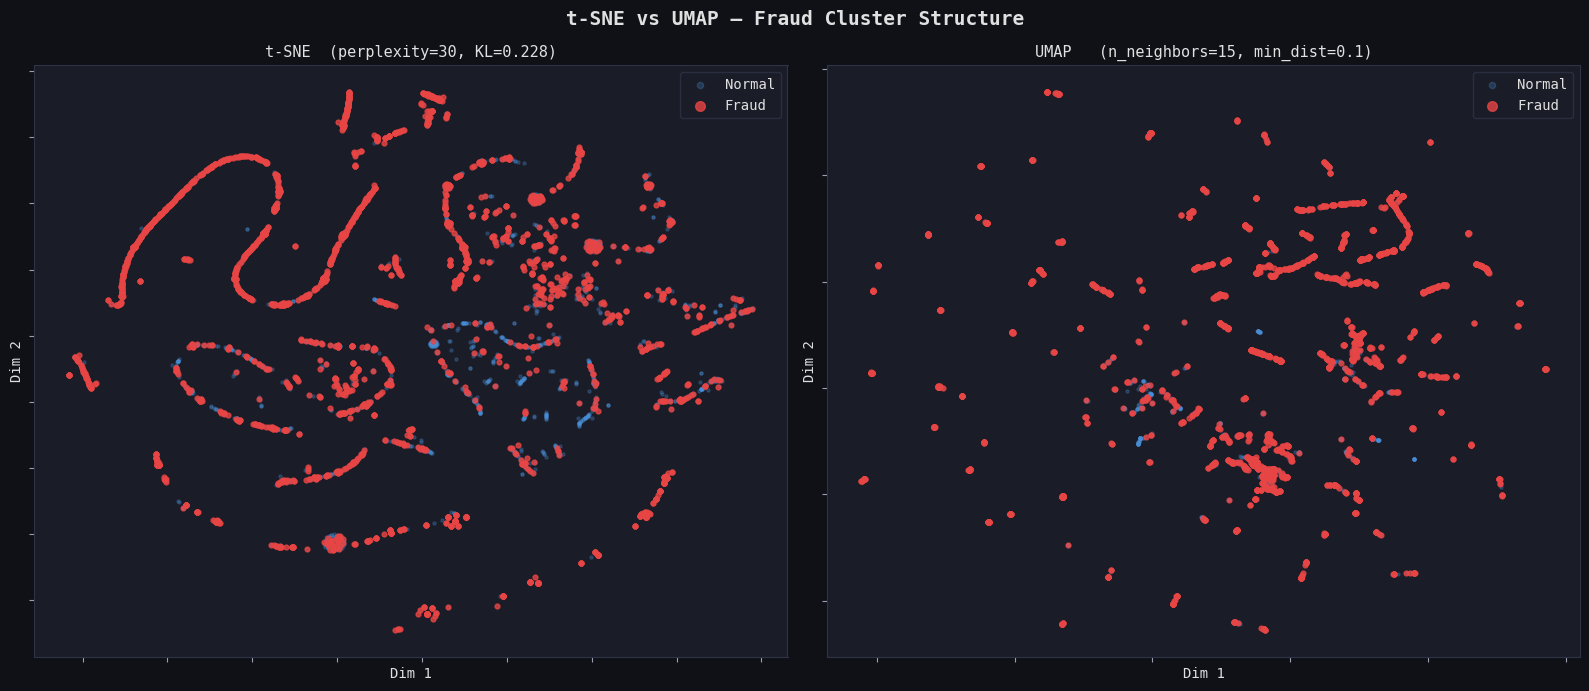


EDA complete. Summary:
  Total transactions : 590,540
  Fraud transactions : 20,663 (3.499%)
  Top KS feature     : V15 (KS=0.3265)
  t-SNE KL divergence: 0.2278
  DR sample size     : 5,000 (2500 fraud + 2500 normal)

Next: 02_features_and_sequences_fixed.ipynb


In [16]:
# Side-by-side: class labels only, both methods, same sample
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('t-SNE vs UMAP — Fraud Cluster Structure',
             fontsize=14, fontweight='bold', color='#E0E0E0')

for ax, X_emb, title in [
    (axes[0], X_tsne, f't-SNE  (perplexity=30, KL={tsne.kl_divergence_:.3f})'),
    (axes[1], X_umap, 'UMAP   (n_neighbors=15, min_dist=0.1)'),
]:
    ax.scatter(X_emb[normal_mask, 0], X_emb[normal_mask, 1],
               c=PAL['normal'], alpha=0.25, s=5, label='Normal')
    ax.scatter(X_emb[fraud_mask,  0], X_emb[fraud_mask,  1],
               c=PAL['fraud'],  alpha=0.8,  s=12, label='Fraud', zorder=5)
    ax.set_title(title, color='#E0E0E0', fontsize=11)
    ax.legend(fontsize=10, markerscale=2)
    ax.tick_params(labelbottom=False, labelleft=False)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')

plt.tight_layout()
plt.savefig(OUT_DIR/'eda/09_tsne_vs_umap.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

print('\nEDA complete. Summary:')
print(f'  Total transactions : {len(df):,}')
print(f'  Fraud transactions : {fraud_count:,} ({fraud_pct:.3f}%)')
print(f'  Top KS feature     : {ks_df.iloc[0]["feature"]} (KS={ks_df.iloc[0]["ks_stat"]:.4f})')
print(f'  t-SNE KL divergence: {tsne.kl_divergence_:.4f}')
print(f'  DR sample size     : {len(sel_idx):,} ({n_fraud_s} fraud + {n_normal_s} normal)')
print()
print('Next: 02_features_and_sequences_fixed.ipynb')